In [2]:
#Cell 1 - Imports
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

#Makes plot look clean
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
#Cell 2 - Load Data

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
 
print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset Shape: (7043, 21)
Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#Cell 3 - Basic Info
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

In [5]:
#Cell 4 - Fix Total Charges 
#Total charges has blank spaces "" instead of NaN
# This is why it loaded as object instead of float

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors="coerce")

#Check how many NaN values got created
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

#See those rows
df[df['TotalCharges'].isnull()]

Missing values in TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [6]:
#Cell 5 - Missing Values
print("Missing Values in Each Column:")
print("=" * 40)

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage' : missing_percent
}).sort_values('Percentage', ascending = False)

print(missing_df[missing_df['Missing Count'] > 0])


Missing Values in Each Column:
              Missing Count  Percentage
TotalCharges             11    0.156183


In [7]:
#Cell 6 - Statistical Summary
print("Numerical Columns Summary:")
df.describe()

Numerical Columns Summary:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Churn Distribution:
 No (Stay): 5174 ( 73.5%)
 Yes (Churn) : 1869 (26.5%)


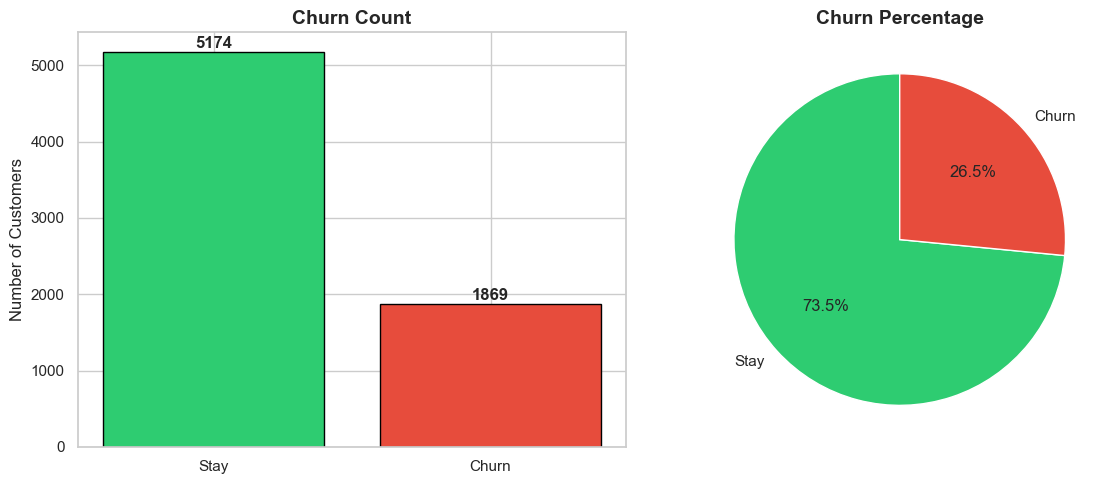


 Class Imbalance Detected - We'll handle this with SMOTE is phase 2


In [9]:
#Cell 7 - Churn Distribution 
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100
print("Churn Distribution:")
print(f" No (Stay): {churn_counts['No']} ({churn_percent['No']: .1f}%)")
print(f" Yes (Churn) : {churn_counts['Yes']} ({churn_percent['Yes']:.1f}%)")

#Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Count plot
axes[0].bar(['Stay', 'Churn'], churn_counts.values, color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')

for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

#Pie chart
axes[1].pie(churn_counts.values, labels=['Stay', 'Churn'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/churn_distribution.png', dpi=150)
plt.show()

print("\n Class Imbalance Detected - We'll handle this with SMOTE is phase 2")

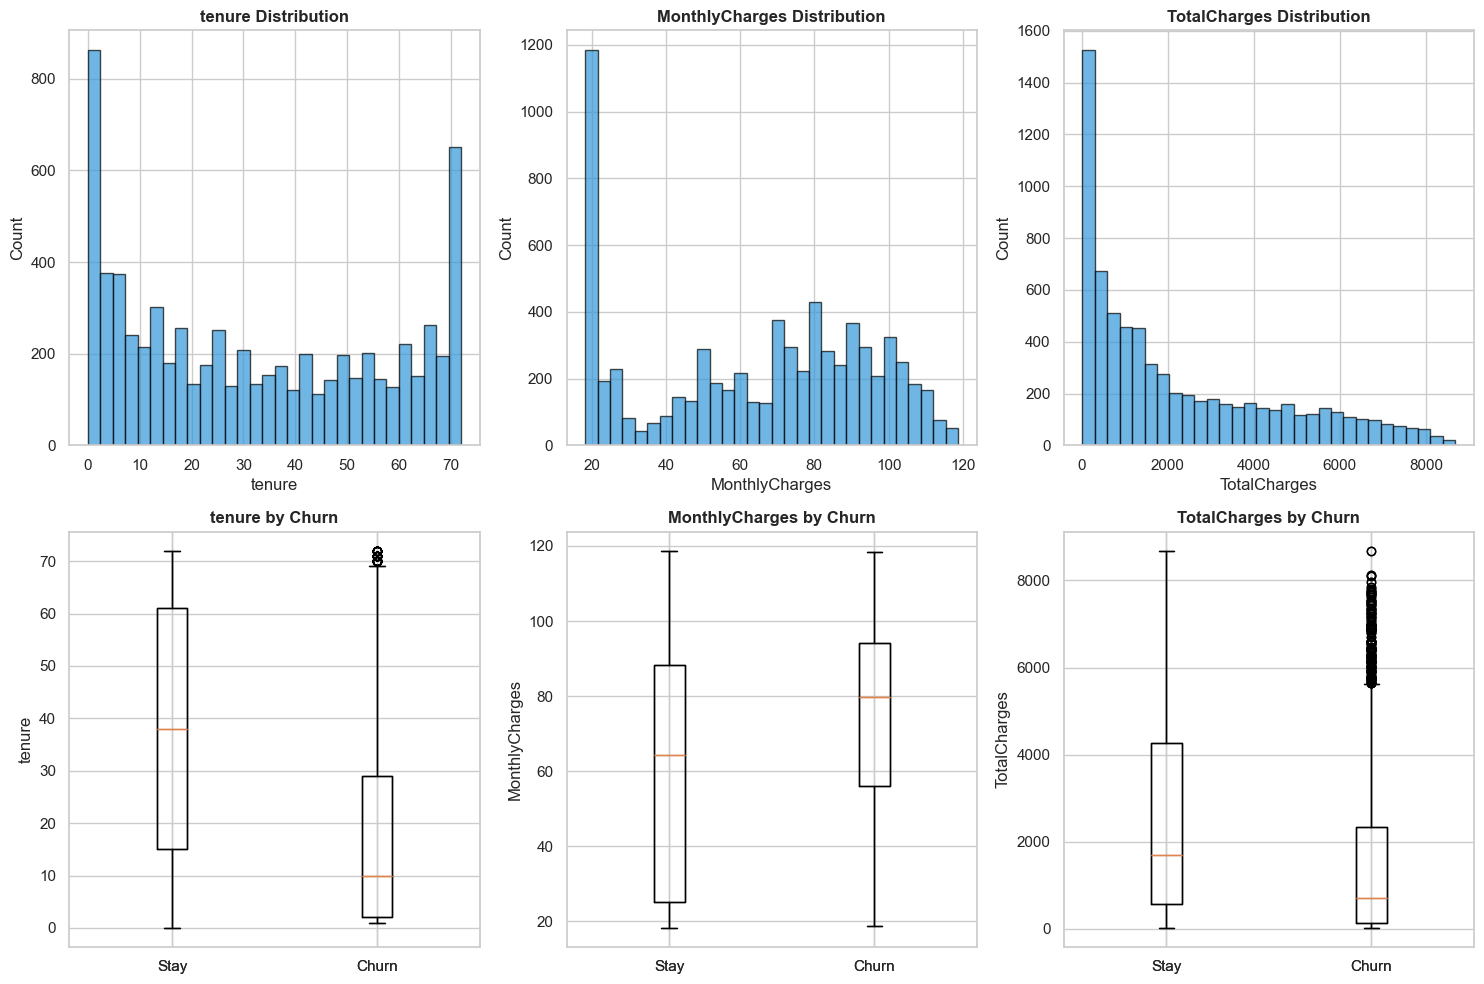

In [10]:
#Cell 8 - Numerical Features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i , col in enumerate(numerical_cols):
    #histogram
    axes[0][i].hist(df[col].dropna(), bins=30,
                    color='#3498db', edgecolor='black', alpha=0.7)
    axes[0][i].set_title(f'{col} Distribution', fontweight='bold')
    axes[0][i].set_xlabel(col)
    axes[0][i].set_ylabel('Count')

    #Boxplot by Churn
    churn_no = df[df['Churn'] == 'No'][col].dropna()
    churn_yes = df[df['Churn'] == 'Yes'][col].dropna()
    axes[1][i].boxplot([churn_no, churn_yes], labels=['Stay', 'Churn'])
    axes[1][i].set_title(f'{col} by Churn', fontweight='bold')
    axes[1][i].set_ylabel(col)
    axes[0][i].set_ylabel('Count')

    #Boxplot by Churn 
    churn_no = df[df['Churn'] == 'No'][col].dropna()
    churn_yes = df[df['Churn'] == 'Yes'][col].dropna()
    axes[1][i].boxplot([churn_no, churn_yes], labels=['Stay', 'Churn'])
    axes[1][i].set_title(f'{col} by Churn', fontweight='bold')
    axes[1][i].set_ylabel(col)

plt.tight_layout()
plt.savefig('../data/processed/numerical_distributions.png', dpi=150)
plt.show()

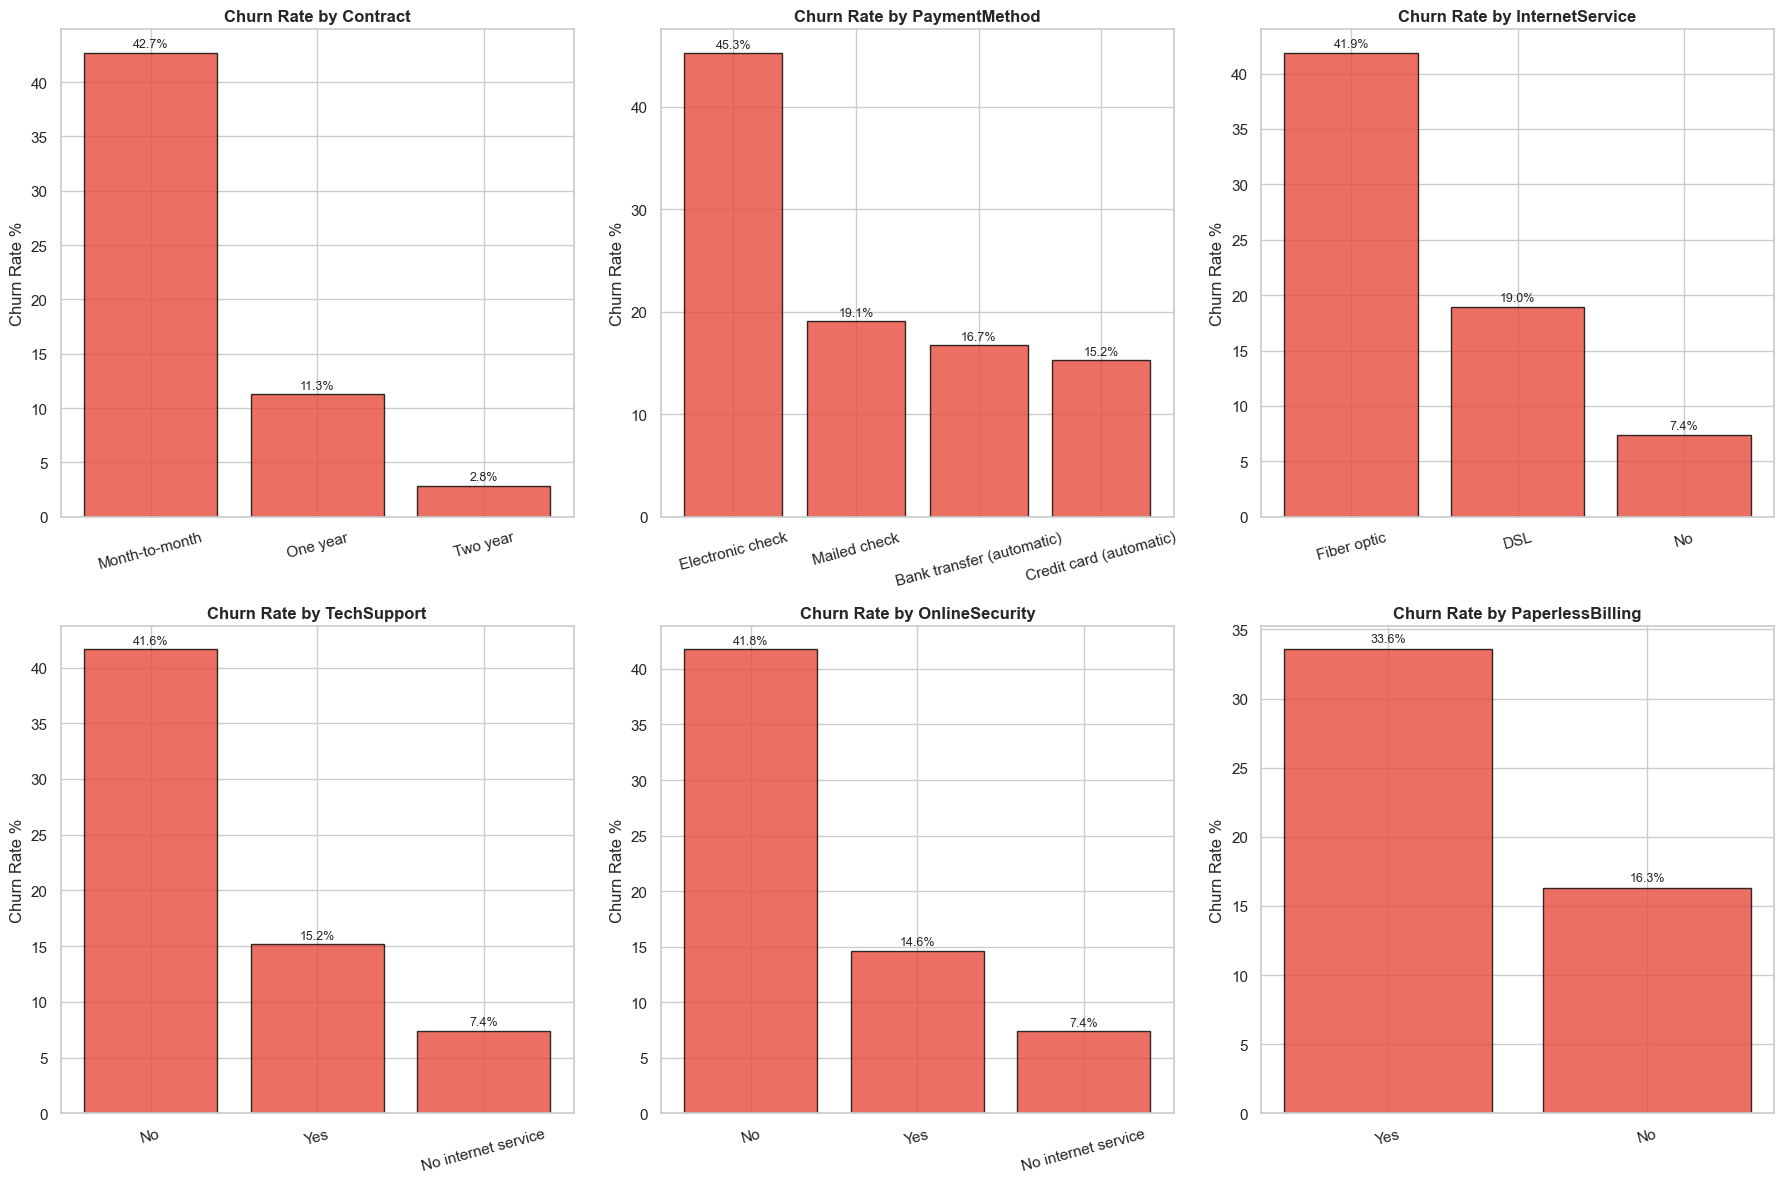

In [14]:
#Cell 9 - Categorical Features vs Churn 
categorical_cols = ['Contract', 'PaymentMethod',
                    'InternetService','TechSupport',
                    'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn Rate %']
    churn_rate = churn_rate.sort_values('Churn Rate %', ascending=False)

    bars = axes[i].bar(churn_rate[col], churn_rate['Churn Rate %'],
                       color='#e74c3c', alpha=0.8, edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate %')
    axes[i].tick_params(axis='x', rotation=15)

    for bar, val in zip(bars, churn_rate['Churn Rate %']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9)
    
plt.tight_layout()
plt.savefig('../data/processed/categorical_churn_rates.png', dpi=150)
plt.show()

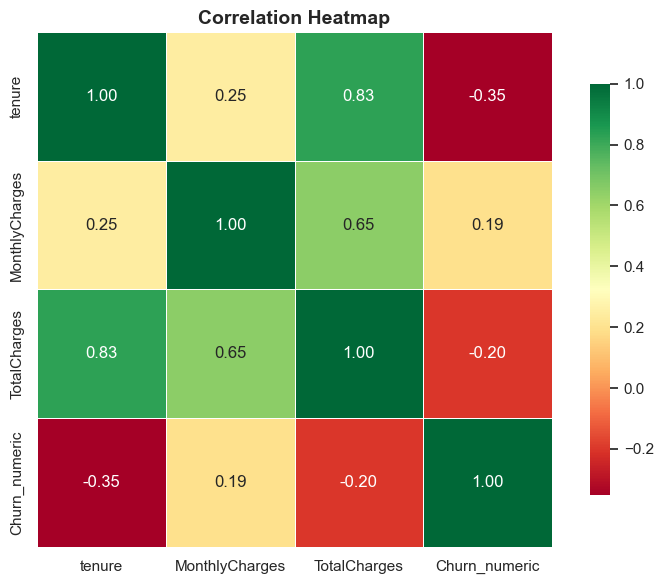

In [15]:
#Cell 10 - Correlation Heatmap
#Convert target to numeric for correlation

df_corr = df.copy()
df_corr['Churn_numeric'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure','MonthlyCharges', 'TotalCharges', 'Churn_numeric']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

In [16]:
#Cell 11 - Key Insights Summary 
print("""
==========================================================
      EDA KEY INSIGHTS SUMMARY
==========================================================
      1.DATASET 
        -7,043 customers, 21 features
        -TotalCharges had 11 missing values (fixed)
      2.CLASS IMBALANCE
        -73.5% Stay | 26.5% Churn
        -Need SMOTE in preprocessing phase
      3.NUMERICAL INSIGHTS
        -Low tenure customers churn more (new customers at risk)
        -High monthly charges linked to higher churn
        -TotalCharges highly correlated with tenure
      4.CATEGORICAL INSIGHTS
        -Month-to-month contract -> highest churn (~43%)
        -Fiber optic users -> churn more
        -No TechSupport / OnlineSecurity -> churn more
      5.WHAT TO DO IN NEXT PHASE
        -Fix Total charges missing values (11 rows)
        -Encode all categorical columns
        -Drop customerID (not useful)
        -Apply SMOTE for class imbalance
===============================================================
""")


      EDA KEY INSIGHTS SUMMARY
      1.DATASET 
        -7,043 customers, 21 features
        -TotalCharges had 11 missing values (fixed)
      2.CLASS IMBALANCE
        -73.5% Stay | 26.5% Churn
        -Need SMOTE in preprocessing phase
      3.NUMERICAL INSIGHTS
        -Low tenure customers churn more (new customers at risk)
        -High monthly charges linked to higher churn
        -TotalCharges highly correlated with tenure
      4.CATEGORICAL INSIGHTS
        -Month-to-month contract -> highest churn (~43%)
        -Fiber optic users -> churn more
        -No TechSupport / OnlineSecurity -> churn more
      5.WHAT TO DO IN NEXT PHASE
        -Fix Total charges missing values (11 rows)
        -Encode all categorical columns
        -Drop customerID (not useful)
        -Apply SMOTE for class imbalance

